# EDA — анализ и предобработка датасета недвижимости

## 1.1 Знакомство с данными


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

# Загрузка данных
file_path = 'real_estate_data.csv'
df = pd.read_csv(file_path, low_memory=False)



print('Размерность:', df.shape)
print('\nСтолбцы:')
print(df.columns.tolist())
print('\nТипы данных:')
print(df.dtypes)


Размерность: (403487, 17)

Столбцы:
['id', 'type', 'sub_type', 'start_date', 'end_date', 'listing_type', 'tom', 'building_age', 'total_floor_count', 'floor_no', 'room_count', 'size', 'address', 'furnished', 'heating_type', 'price', 'price_currency']

Типы данных:
id                     int64
type                     str
sub_type                 str
start_date               str
end_date                 str
listing_type           int64
tom                    int64
building_age             str
total_floor_count        str
floor_no                 str
room_count               str
size                 float64
address                  str
furnished            float64
heating_type             str
price                float64
price_currency           str
dtype: object


In [2]:
# Первые, последние и случайная строки
print('Первые 5 строк:')
display(df.head())

print('Последние 5 строк:')
display(df.tail())

print('Случайная строка:')
display(df.sample(1, random_state=42))


Первые 5 строк:


,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
0,1,Konut,Rezidans,12/10/18,1/9/19,2,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,3500.0,TRY
1,2,Konut,Daire,2/13/19,NaN,1,14,0,20 ve üzeri,20 ve üzeri,1+0,43.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,490000.0,TRY
2,3,Konut,Daire,10/9/18,11/8/18,1,30,0,1,Yüksek Giriş,2+1,NaN,Tekirdağ/Çorlu/Reşadiye,NaN,Fancoil,155000.0,TRY
3,4,Konut,Rezidans,9/10/18,10/10/18,1,30,3,20 ve üzeri,20 ve üzeri,6+1,450.0,İstanbul/Beşiktaş/Levent,NaN,Fancoil,32500000.0,TRY
4,5,Konut,Rezidans,12/10/18,1/9/19,1,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,1450000.0,TRY


Последние 5 строк:


,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
403482,403483,Konut,Daire,9/18/18,NaN,2,162,NaN,NaN,NaN,+,NaN,İstanbul/Sultanbeyli/Adil,NaN,NaN,1500.0,TRY
403483,403484,Konut,Daire,10/11/18,NaN,1,139,NaN,NaN,NaN,2+1,NaN,Sakarya/Adapazarı/Cumhuriyet,NaN,NaN,120000.0,TRY
403484,403485,Konut,Daire,11/22/18,NaN,1,97,NaN,NaN,NaN,1+1,NaN,Antalya/Alanya/Saray,NaN,NaN,48000.0,EUR
403485,403486,Konut,Daire,2/21/19,NaN,2,6,NaN,NaN,NaN,2+1,2.0,Aydın/Kuşadası/Türkmen,NaN,NaN,900.0,TRY
403486,403487,Konut,Daire,1/15/19,1/18/19,1,3,NaN,NaN,NaN,3+1,140.0,Kayseri/Melikgazi/Alpaslan,NaN,NaN,210000.0,TRY


Случайная строка:


,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
60623,60624,Konut,Daire,11/20/18,2/23/19,1,95,6-10 arası,5,1,2+1,120.0,Antalya/Alanya/Oba,NaN,Klima,240000.0,TRY


### Краткое описание признаков

- id — идентификатор объявления;
- type, sub_type — тип и подтип недвижимости;
- start_date, end_date — даты публикации и окончания объявления;
- listing_type — тип объявления;
- tom — срок размещения;
- building_age — возраст здания;
- total_floor_count, floor_no — этажность дома и этаж объекта;
- room_count — количество комнат;
- size — площадь;
- address — адрес;
- furnished — признак меблировки;
- heating_type — тип отопления;
- price — цена, целевая переменная;
- price_currency — валюта цены.

Основной интерес представляют площадь, количество комнат, возраст здания, срок размещения, тип недвижимости и местоположение, так как они могут быть связаны с ценой.

## 1.2 Описательная статистика


In [3]:
# Базовая статистика числовых признаков
numeric_cols = df.select_dtypes(include=np.number).columns
stats = df[numeric_cols].describe().T
stats['median'] = df[numeric_cols].median()
stats['skewness'] = df[numeric_cols].skew()
stats[['min','25%','median','mean','75%','max','std','skewness']]


,min,25%,median,mean,75%,max,std,skewness
id,1.0,100872.5,201744.0,201744.000000,302615.5,4.034870e+05,1.164768e+05,0.000000
listing_type,1.0,1.0,1.0,1.294235,2.0,3.000000e+00,4.677333e-01,1.065096
tom,0.0,29.0,40.0,57.022739,90.0,1.800000e+02,4.435893e+01,0.836624
size,1.0,85.0,110.0,279.349094,140.0,9.482350e+05,9.429195e+03,77.653355
furnished,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,-250.0,2500.0,199000.0,354641.661933,342000.0,2.000000e+09,4.809503e+06,308.507027


In [4]:
# Частоты и количество уникальных значений категориальных признаков
cat_cols = df.select_dtypes(include='object').columns
cat_summary = pd.DataFrame({
    'unique': df[cat_cols].nunique(dropna=True),
    'missing': df[cat_cols].isna().sum()
}).sort_values('unique', ascending=False)
display(cat_summary)

for col in ['sub_type', 'building_age', 'room_count', 'heating_type', 'price_currency']:
    print(f'\n--- {col} ---')
    display(df[col].value_counts(dropna=False).head(10))


C:\Users\208-3\AppData\Local\Temp\ipykernel_576\2879969140.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


,unique,missing
address,7842,0
start_date,181,0
end_date,181,137189
room_count,37,0
floor_no,35,35296
heating_type,16,27970
building_age,14,27390
sub_type,12,0
total_floor_count,12,28021
price_currency,4,715



--- sub_type ---


sub_type
Daire                  354549
Villa                   21324
Müstakil Ev              9563
Rezidans                 7716
Yazlık                   5929
Komple Bina              2607
Prefabrik Ev              679
Çiftlik Evi               528
Köşk / Konak / Yalı       301
Yalı Dairesi              187
Name: count, dtype: int64


--- building_age ---


...

room_count
3+1    157363
2+1    138677
1+1     39134
4+1     37472
5+1      8219
4+2      4540
5+2      2926
+        2898
3+2      2673
1+0      2612
Name: count, dtype: int64


--- heating_type ---


heating_type
Kombi (Doğalgaz)                   204150
Klima                               68197
Merkezi Sistem (Isı Payı Ölçer)     30595
NaN                                 27970
Merkezi Sistem                      22855
Kalorifer (Doğalgaz)                10928
Soba (Kömür)                         8450
Yerden Isıtma                        6958
Yok                                  6098
Kat Kaloriferi                       5655
Name: count, dtype: int64


--- price_currency ---


price_currency
TRY    400677
EUR       922
NaN       715
GBP       621
USD       552
Name: count, dtype: int64

Средняя цена: 354641.66193280567
Медиана цены: 199000.0
Асимметрия цены: 308.5070265745684


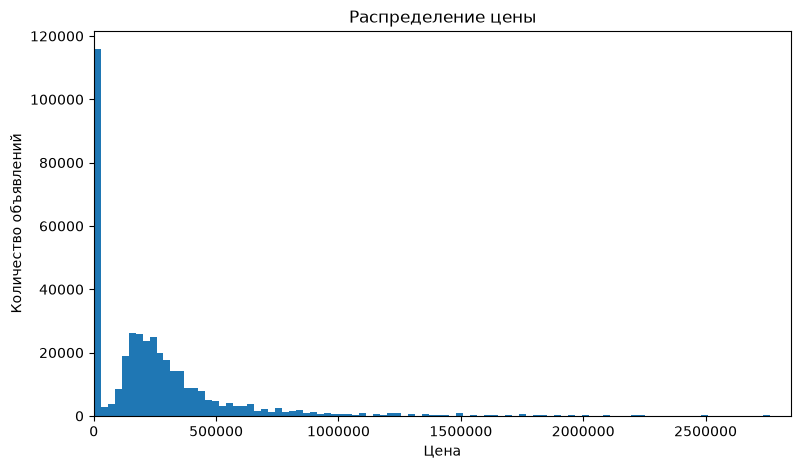

In [5]:
# Распределение цены и её асимметрия
price = df['price'].dropna()
print('Средняя цена:', price.mean())
print('Медиана цены:', price.median())
print('Асимметрия цены:', price.skew())

plt.figure(figsize=(9,5))
plt.hist(price, bins=100, range=(0, price.quantile(0.99)))
plt.title('Распределение цены')
plt.xlabel('Цена')
plt.ylabel('Количество объявлений')
plt.xlim(0, price.quantile(0.99))
plt.ticklabel_format(style='plain', axis='x')
plt.show()


**Замечание:** в данных цена указана в разных валютах (`TRY`, `EUR`, `GBP`, `USD`), поэтому прямое сравнение всех значений цены не совсем корректно. Для основной части анализа ниже используется валюта `TRY`, которая сильно преобладает в наборе.


In [6]:
# Подготовка выборки TRY для более корректного сравнения цен
df_try = df[df['price_currency'].eq('TRY') & df['price'].notna()].copy()
print('Количество объявлений в TRY:', len(df_try))
print('Медиана цены TRY:', df_try['price'].median())
print('Средняя цена TRY:', df_try['price'].mean())


Количество объявлений в TRY: 400677
Медиана цены TRY: 200000.0
Средняя цена TRY: 354008.64981019625


## 1.3 Визуальный анализ


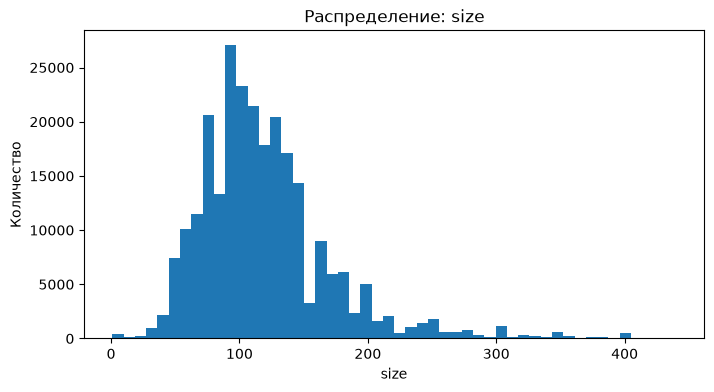

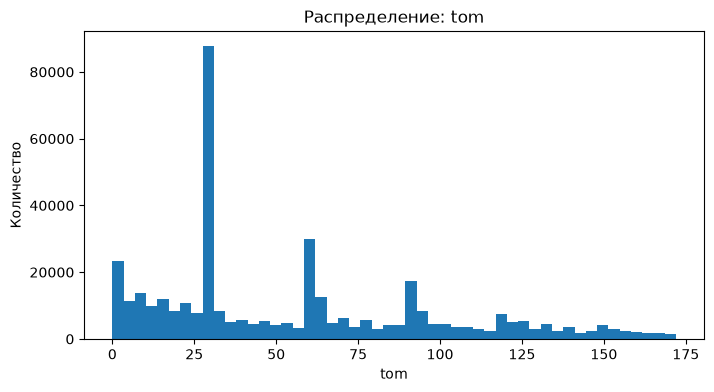

In [7]:
# Гистограммы основных числовых признаков
for col in ['size', 'tom']:
    plt.figure(figsize=(8,4))
    s = df[col].dropna()
    upper = s.quantile(0.99)
    plt.hist(s[s <= upper], bins=50)
    plt.title(f'Распределение: {col}')
    plt.xlabel(col)
    plt.ylabel('Количество')
    plt.show()


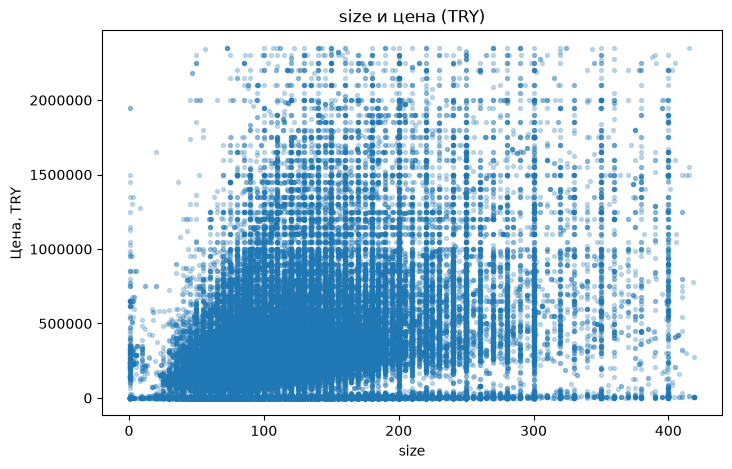

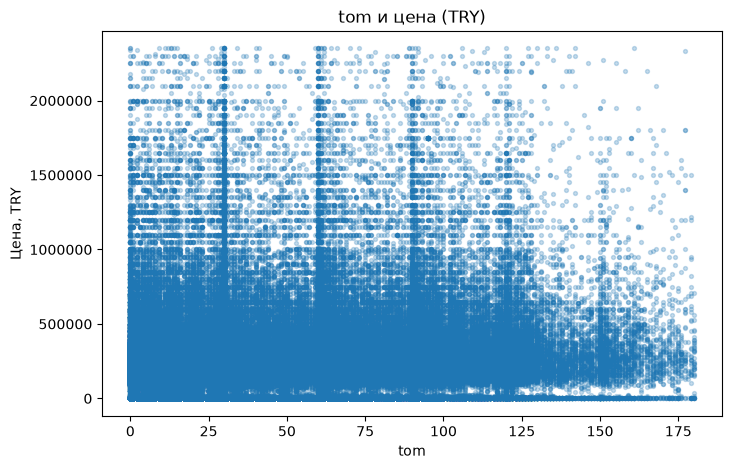

In [8]:
# Точечная диаграмма «признак — цена»
plot_df = df_try[['size','tom','price']].dropna().copy()
plot_df = plot_df[plot_df['size'] <= plot_df['size'].quantile(0.99)]
plot_df = plot_df[plot_df['price'] <= plot_df['price'].quantile(0.99)]

for col in ['size','tom']:
    plt.figure(figsize=(8,5))
    plt.scatter(plot_df[col], plot_df['price'], alpha=0.25, s=8)
    plt.title(f'{col} и цена (TRY)')
    plt.xlabel(col)
    plt.ylabel('Цена, TRY')
    plt.ticklabel_format(style='plain', axis='y')
    plt.show()


C:\Users\208-3\AppData\Local\Temp\ipykernel_576\1662202755.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(temp[col], vert=False)


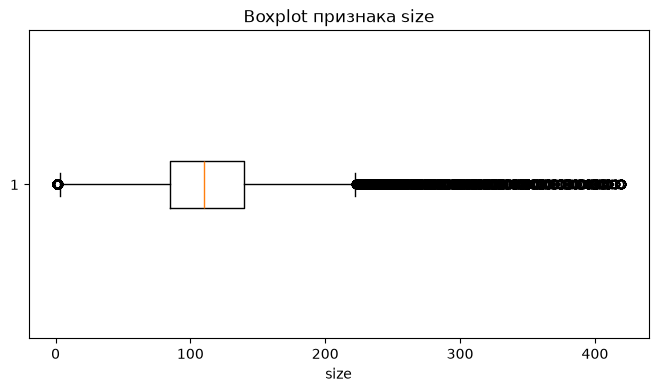

C:\Users\208-3\AppData\Local\Temp\ipykernel_576\1662202755.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(temp[col], vert=False)


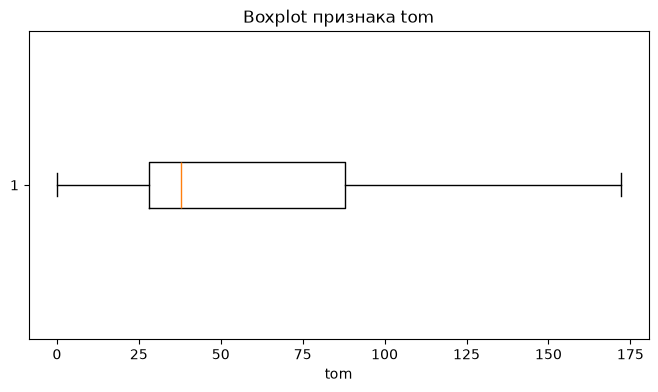

In [9]:
# Boxplot цены по основным числовым признакам
for col in ['size', 'tom']:
    temp = df_try[[col,'price']].dropna()
    temp = temp[temp[col] <= temp[col].quantile(0.99)]
    temp = temp[temp['price'] <= temp['price'].quantile(0.99)]
    plt.figure(figsize=(8,4))
    plt.boxplot(temp[col], vert=False)
    plt.title(f'Boxplot признака {col}')
    plt.xlabel(col)
    plt.show()


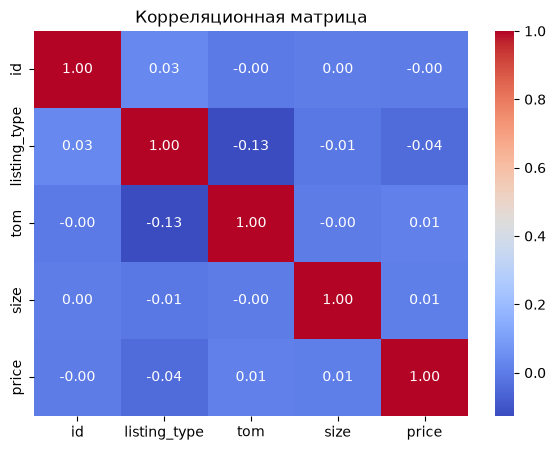

,corr_with_price
price,1.000000
tom,0.011871
size,0.006354
id,-0.002072
listing_type,-0.044194


In [10]:
# Корреляция числовых признаков
corr_cols = ['id','listing_type','tom','size','price']
corr = df_try[corr_cols].corr()

plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Корреляционная матрица')
plt.show()

display(corr['price'].sort_values(ascending=False).to_frame('corr_with_price'))


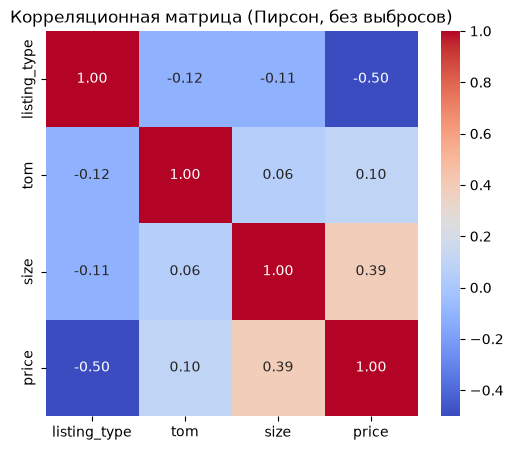

,corr_clipped_with_price
price,1.000000
size,0.388731
tom,0.102687
listing_type,-0.500421


In [11]:
# Корреляция числовых признаков
corr_cols = ['listing_type', 'tom', 'size', 'price']
temp = df_try[corr_cols].dropna()
temp = temp[temp['price'] <= temp['price'].quantile(0.99)]
temp = temp[temp['size'] <= temp['size'].quantile(0.99)]
corr_clipped = temp.corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr_clipped, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Корреляционная матрица (Пирсон, без выбросов)')
plt.show()
display(corr_clipped['price'].sort_values(ascending=False).to_frame('corr_clipped_with_price'))

,mean,median,count
sub_type,,,
Köşk / Konak / Yalı,2.004990e+07,2400000.0,281
Komple Bina,2.303302e+06,720000.0,2573
Yalı Dairesi,2.274994e+06,40000.0,175
Çiftlik Evi,1.998237e+06,600000.0,516
Villa,1.253458e+06,680000.0,20765
Rezidans,7.534345e+05,239000.0,7475
Loft,7.017662e+05,457500.0,34
Müstakil Ev,6.311821e+05,350000.0,9445
Yazlık,4.186805e+05,360000.0,5888


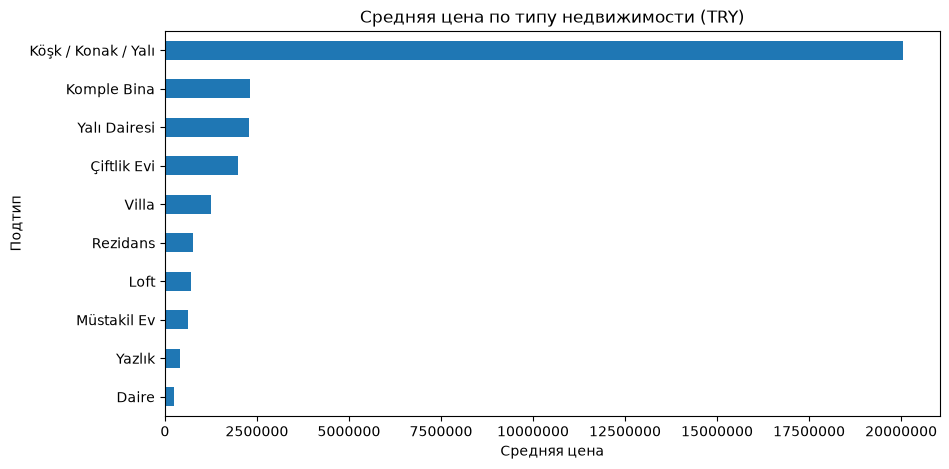

In [12]:
# Средняя цена по подтипам недвижимости
subtype_price = (df_try.groupby('sub_type')['price']
                 .agg(['mean','median','count'])
                 .sort_values('mean', ascending=False)
                 .head(10))
display(subtype_price)

plt.figure(figsize=(10,5))
subtype_price['mean'].sort_values().plot(kind='barh')
plt.title('Средняя цена по типу недвижимости (TRY)')
plt.xlabel('Средняя цена')
plt.ylabel('Подтип')
plt.ticklabel_format(style='plain', axis='x')
plt.show()


,mean,median,count
room_count,,,
3+1,2.959587e+05,229000.0,156800
2+1,1.925234e+05,170000.0,138065
1+1,1.248825e+05,99000.0,38880
4+1,5.800454e+05,380000.0,37218
5+1,9.612501e+05,449000.0,8145
4+2,7.637296e+05,450000.0,4505
5+2,1.521712e+06,600000.0,2871
3+2,5.211432e+05,375000.0,2647
1+0,1.083951e+05,1000.0,2580


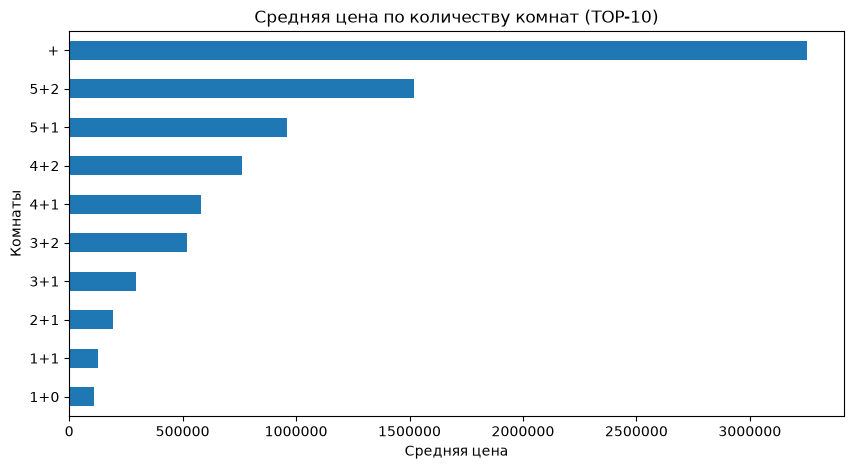

In [13]:
# Средняя цена по количеству комнат
room_price = (df_try.groupby('room_count')['price']
              .agg(['mean','median','count'])
              .sort_values('count', ascending=False)
              .head(10))
display(room_price)

plt.figure(figsize=(10,5))
room_price['mean'].sort_values().plot(kind='barh')
plt.title('Средняя цена по количеству комнат (TOP-10)')
plt.xlabel('Средняя цена')
plt.ylabel('Комнаты')
plt.ticklabel_format(style='plain', axis='x')
plt.show()


## 1.4 Анализ пропусков и аномалий


,Количество пропусков,"Доля пропусков, %"
furnished,403487,100.00
size,146006,36.19
end_date,137189,34.00
floor_no,35296,8.75
total_floor_count,28021,6.94
heating_type,27970,6.93
building_age,27390,6.79
price,715,0.18
price_currency,715,0.18
type,0,0.00


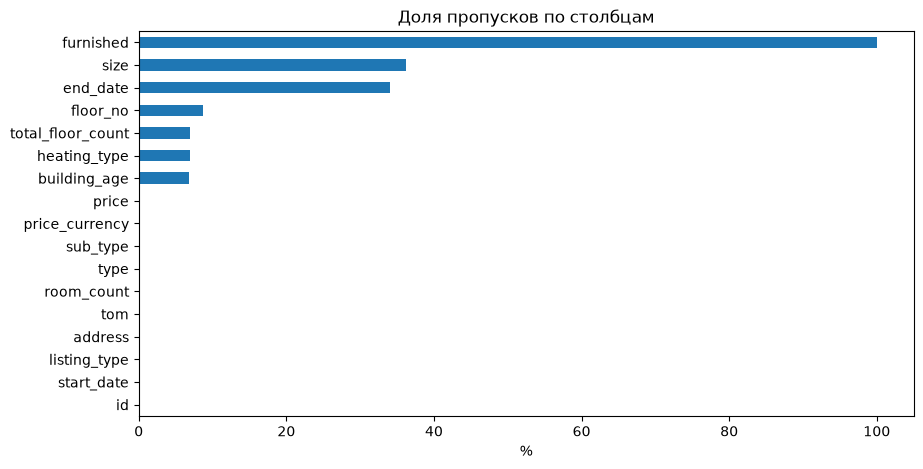

In [14]:
# Таблица пропусков
missing = pd.DataFrame({
    'Количество пропусков': df.isna().sum(),
    'Доля пропусков, %': (df.isna().mean()*100).round(2)
}).sort_values('Количество пропусков', ascending=False)
display(missing)

plt.figure(figsize=(10,5))
missing['Доля пропусков, %'].sort_values(ascending=True).plot(kind='barh')
plt.title('Доля пропусков по столбцам')
plt.xlabel('%')
plt.show()


In [15]:
# Дубликаты
print('Полных дубликатов:', df.duplicated().sum())
print('Дубликатов по id:', df['id'].duplicated().sum())


Полных дубликатов: 0
Дубликатов по id: 0


In [16]:
# Проверка логической согласованности и подозрительных значений
print('Отрицательная цена:', (df['price'] < 0).sum())
print('Цена равна нулю:', (df['price'] == 0).sum())
print('Нулевая/отрицательная площадь:', (df['size'] <= 0).sum())
print('Очень большая площадь (> 10000):', (df['size'] > 10000).sum())
print('Очень большая цена (> 100 млн):', (df['price'] > 100_000_000).sum())

print('\nПримеры подозрительных цен:')
display(df.loc[df['price'] <= 0, ['id','sub_type','address','price','price_currency']].head(10))


Отрицательная цена: 1
Цена равна нулю: 44
Нулевая/отрицательная площадь: 0
Очень большая площадь (> 10000): 148
Очень большая цена (> 100 млн): 28

Примеры подозрительных цен:


,id,sub_type,address,price,price_currency
941,942,Rezidans,İstanbul/Ataşehir/Küçükbakkalköy,0.0,TRY
1173,1174,Komple Bina,İzmir/Konak/Duatepe,0.0,TRY
1181,1182,Rezidans,İstanbul/Ataşehir/Küçükbakkalköy,0.0,TRY
1356,1357,Rezidans,İzmir/Buca/Yıldız,0.0,TRY
25130,25131,Yazlık,Muğla/Fethiye/Kayaköy,0.0,TRY
33965,33966,Yazlık,İzmir/Çeşme/Çiftlik,0.0,TRY
75354,75355,Daire,İstanbul/Bakırköy/Cevizlik,0.0,TRY
77016,77017,Daire,Aydın/Didim/Efeler,0.0,TRY
79139,79140,Daire,İstanbul/Beylikdüzü/Cumhuriyet,0.0,TRY
79722,79723,Villa,Aydın/Didim/Akbük,0.0,TRY


In [17]:
# Проверка столбца furnished
print('Количество непустых значений furnished:', df['furnished'].notna().sum())
print('Уникальные значения furnished:', df['furnished'].dropna().unique())


Количество непустых значений furnished: 0
Уникальные значения furnished: []


## 1.5 Промежуточные выводы

1. **Площадь объекта, вероятно, является одним из наиболее важных факторов цены.** Это можно проверить по точечной диаграмме `size — price` и коэффициенту корреляции.
2. **Тип недвижимости влияет на стоимость.** Средние цены для разных `sub_type` заметно отличаются, поэтому виллы, резиденции, квартиры и другие типы нельзя считать одинаковыми объектами.
3. **Количество комнат связано с ценой**, однако зависимость может быть не строго линейной, поэтому одного этого признака недостаточно для объяснения стоимости.
4. **В данных присутствуют выбросы по цене и площади.** Например, встречаются очень большие площади и цены, которые сильно отличаются от основной массы объявлений. Это может заметно влиять на среднее значение и корреляции.
5. **Пропуски являются отдельной проблемой.** Особенно много пропусков наблюдается в `size`, `end_date` и некоторых характеристиках объекта. Кроме того, `furnished` полностью пустой и в дальнейшем этот столбец, скорее всего, можно удалить.

**Итог:** перед построением модели прогнозирования цены необходимо привести типы данных к удобному виду, обработать пропуски и выбросы, а также отдельно решить вопрос с разными валютами цен.

# Этап 2. Предварительная обработка данных

Готовим данные для модели прогноза цены. Работаем только с объявлениями в TRY, чтобы не смешивать валюты.

## 2.1 Пропуски

`furnished` полностью пустой — удаляем. Остальные пропуски заполним позже: числа — медианой, категории — самым частым значением.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

df = pd.read_csv('real_estate_data.csv', low_memory=False)
df = df[(df['price_currency'] == 'TRY') & df['price'].notna() & (df['price'] > 0)].copy()

print('Размер после отбора:', df.shape)
df.isna().sum().sort_values(ascending=False).head(10)


In [ ]:
# Даты -> длительность объявления в днях; убираем ненужные столбцы
df['listing_days'] = (pd.to_datetime(df['end_date'], errors='coerce')
                       - pd.to_datetime(df['start_date'], errors='coerce')).dt.days

df = df.drop(columns=['furnished', 'start_date', 'end_date', 'id', 'price_currency', 'type'])
print('Осталось столбцов:', df.shape[1])


**Почему так:** медиана устойчивее к выбросам, чем среднее, поэтому для чисел используем её. Для категорий берём самое частое значение — это тоже простой и надёжный вариант.

## 2.2 Выбросы

Слишком большая площадь искажает модель. Логарифмируем `size`, чтобы сгладить выбросы. Цену не трогаем — это целевая переменная.

In [ ]:
for col in ['size', 'tom']:
    print(col, '1%–99%:', df[col].quantile(0.01), '—', df[col].quantile(0.99))

df['size_log'] = np.log1p(df['size'].clip(lower=0))

df['size_log'].hist(bins=50, figsize=(8, 4))
plt.title('Логарифмированная площадь')
plt.xlabel('log(1 + size)')
plt.show()


## 2.3 Категориальные признаки

`address` не кодируем — слишком много уникальных значений. `room_count` (например `3+1`) превращаем в одно число комнат.

In [ ]:
def room_to_number(x):
    if pd.isna(x):
        return np.nan
    parts = str(x).split('+')
    try:
        return sum(float(p) for p in parts)
    except ValueError:
        return np.nan

df['room_count_num'] = df['room_count'].apply(room_to_number)
df = df.drop(columns=['room_count', 'address'])
df['room_count_num'].head()


## 2.4 Новые признаки

Возраст здания и этажность заданы диапазонами (`6-10 arası`, `40 ve üzeri`). Берём середину диапазона, а верхний предел заменяем одним числом.

In [ ]:
# Одна функция для обоих признаков: диапазон -> среднее, верхний предел -> число
def range_to_number(x, cap_marker, cap_value):
    if pd.isna(x):
        return np.nan
    x = str(x)
    if cap_marker in x:
        return cap_value
    if '-' in x:
        try:
            a, b = x.split('-')
            return (float(a) + float(b.split()[0])) / 2
        except ValueError:
            return np.nan
    try:
        return float(x)
    except ValueError:
        return np.nan

df['building_age_num'] = df['building_age'].apply(lambda x: range_to_number(x, '40 ve', 40))
df['total_floor_num'] = df['total_floor_count'].apply(lambda x: range_to_number(x, '20 ve', 20))

df = df.drop(columns=['building_age', 'total_floor_count', 'floor_no'])
print('Размер после Feature Engineering:', df.shape)
df.head()


`price_per_m2` не добавляем — он считается через `price`, а это наша целевая переменная. Добавить его — значит устроить утечку данных.

## 2.5 Масштабирование

Числовые признаки приводим к одному масштабу через `StandardScaler`. Категории после One-Hot Encoding дополнительно не масштабируем.

## 2.6 Разбиение данных

Сначала делим на train / validation / test, и только потом обучаем препроцессинг — на train. Так медиана, категории и масштаб не «подглядывают» в validation/test.

In [ ]:
X = df.drop(columns=['price'])
y = df['price']

# 70% train, 15% validation, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print('Train:', X_train.shape, '| Validation:', X_val.shape, '| Test:', X_test.shape)


In [ ]:
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')),
                       ('scaler', StandardScaler())]), numeric_cols),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                       ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), categorical_cols),
])

# Обучаем только на train, применяем ко всем выборкам
X_train_ready = preprocessor.fit_transform(X_train)
X_val_ready = preprocessor.transform(X_val)
X_test_ready = preprocessor.transform(X_test)

print('Признаков после обработки:', X_train_ready.shape[1])


In [ ]:
# Проверка, что пропусков не осталось
print('NaN train/val/test:', np.isnan(X_train_ready).sum(), np.isnan(X_val_ready).sum(), np.isnan(X_test_ready).sum())


### Итог этапа 2

- Убрали пустой столбец и лишние технические признаки
- Заполнили пропуски: числа — медианой, категории — самым частым значением
- Сгладили выброс площади через логарифм
- Числовые диапазоны (комнаты, возраст, этажность) свели к одному числу
- Категории закодировали One-Hot Encoding, числа — масштабировали
- Разбили данные на **train (70%) / validation (15%) / test (15%)**, все преобразования обучены только на train


# Этап 3. Построение модели регрессии

Продолжение ноутбука после этапа 2. Код этапов 1–2 выше не менялся.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

RANDOM_STATE = 42

## 3.0 Пересборка данных
**Два решения уровня этапа 3:**
1. Оставляем только объявления о **продаже** (`listing_type == 1`) — объявления о долгосрочной/посуточной аренде находятся на совсем другой шкале цен и портят модель, если их не отделить.
2. Обрезаем экстремальные выбросы цены (2%–98% перцентиль) — в данных встречаются записи вроде «дом за 1.65 млрд TRY», это явные ошибки ввода.


На этом этапе мы очищаем данные о продаже недвижимости от выбросов и лишних колонок, создаём новые признаки и через препроцессор превращаем всё в готовые числовые матрицы, разделённые на train/val/test для обучения моделей прогноза цены.



In [ ]:
df = pd.read_csv('real_estate_data.csv', low_memory=False)
df = df[(df['price_currency'] == 'TRY') & df['price'].notna() & (df['price'] > 0)].copy()
df = df[df['listing_type'] == 1].drop(columns=['listing_type'])
price_low, price_high = df['price'].quantile([0.02, 0.98])
df = df[(df['price'] >= price_low) & (df['price'] <= price_high)].copy()

df['listing_days'] = (pd.to_datetime(df['end_date'], errors='coerce')
                       - pd.to_datetime(df['start_date'], errors='coerce')).dt.days
df = df.drop(columns=['furnished', 'start_date', 'end_date', 'id', 'price_currency', 'type'])

df['size_log'] = np.log1p(df['size'].clip(lower=0))

def room_to_number(x):
    if pd.isna(x):
        return np.nan
    parts = str(x).split('+')                                         
    try:
        return sum(float(p) for p in parts)
    except ValueError:
        return np.nan

df['room_count_num'] = df['room_count'].apply(room_to_number)
df = df.drop(columns=['room_count', 'address'])

def range_to_number(x, cap_marker, cap_value):
    if pd.isna(x):
        return np.nan
    x = str(x)
    if cap_marker in x:
        return cap_value
    if '-' in x:
        try:
            a, b = x.split('-')
            return (float(a) + float(b.split()[0])) / 2
        except ValueError:
            return np.nan
    try:
        return float(x)
    except ValueError:
        return np.nan

df['building_age_num'] = df['building_age'].apply(lambda x: range_to_number(x, '40 ve', 40))
df['total_floor_num'] = df['total_floor_count'].apply(lambda x: range_to_number(x, '20 ve', 20))
df = df.drop(columns=['building_age', 'total_floor_count', 'floor_no'])

X = df.drop(columns=['price'])
y = df['price']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE)

numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')),
                       ('scaler', StandardScaler())]), numeric_cols),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                       ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), categorical_cols),
])

X_train_ready = preprocessor.fit_transform(X_train)
X_val_ready = preprocessor.transform(X_val)
X_test_ready = preprocessor.transform(X_test)

print('Train/val/test:', X_train_ready.shape, X_val_ready.shape, X_test_ready.shape)

## 3.1–3.2 Модели и подбор гиперпараметров

4 модели разной природы: линейная (Ridge), дерево решений, бэггинг (RandomForest), бустинг (GradientBoosting). Для каждой — подбор гиперпараметров с кросс-валидацией (GridSearchCV / RandomizedSearchCV).

In [ ]:
# 4 модели разной природы: линейная, дерево, бэггинг (RandomForest), бустинг (GradientBoosting)

model_grids = {
    'Ridge': (
        Ridge(random_state=RANDOM_STATE),
        {'alpha': [0.1, 1.0, 5.0, 10.0, 50.0]},
        'grid'
         # Сетка гиперпараметров: перебираем силу регуляризации alpha
    ),
    'DecisionTree': (
        DecisionTreeRegressor(random_state=RANDOM_STATE),
        {'max_depth': [4, 6, 8, 10, 12, None], 'min_samples_leaf': [1, 5, 10]},
        'grid'
          # Сетка: max_depth — максимальная глубина дерева (None = без ограничения);
        # min_samples_leaf — минимальное число объектов в листе
    ),
    'RandomForest': (
        RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        {'n_estimators': [100, 200], 'max_depth': [8, 12, 16, None],
         'min_samples_leaf': [1, 2, 5]},
        'random'
         # Сетка: n_estimators — число деревьев; max_depth — глубина; min_samples_leaf — минимум в листе
    ),
    'GradientBoosting': (
        GradientBoostingRegressor(random_state=RANDOM_STATE),
        {'n_estimators': [100, 200, 300], 'max_depth': [2, 3, 4],
         'learning_rate': [0.03, 0.05, 0.1]},
        'random'
          # Сетка: число деревьев, глубина и скорость обучения (learning_rate)
    ),
}

fitted_models = {}
for name, (estimator, grid, search_type) in model_grids.items():
    print(f'\nПодбор гиперпараметров: {name}...')
    if search_type == 'grid':
        search = GridSearchCV(estimator, grid, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
    else:
        search = RandomizedSearchCV(estimator, grid, n_iter=10, cv=5,
                                     scoring='neg_mean_absolute_error',
                                     random_state=RANDOM_STATE, n_jobs=-1)
    search.fit(X_train_ready, y_train)
    fitted_models[name] = search.best_estimator_
    print(f'{name}: лучшие параметры = {search.best_params_}')

## 3.3 Метрики качества

MAE, RMSE, MAPE, R² для каждой модели на validation.

In [ ]:
def compute_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred) ** 0.5,
        'MAPE': mean_absolute_percentage_error(y_true, y_pred) * 100,
        'R2': r2_score(y_true, y_pred),
    }

results = []
for name, model in fitted_models.items():
    val_pred = model.predict(X_val_ready)
    metrics = compute_metrics(y_val, val_pred)
    metrics['model'] = name
    results.append(metrics)

results_df = pd.DataFrame(results).set_index('model')[['MAE', 'RMSE', 'MAPE', 'R2']]
print('\nСравнение моделей на validation:')
display(results_df)

## 3.4 Сравнение моделей

In [ ]:
results_df[['MAE', 'RMSE']].plot(kind='bar', figsize=(8, 5), title='MAE / RMSE по моделям (validation)')
plt.ylabel('Ошибка, TRY')
plt.xticks(rotation=0)
plt.show()

results_df['R2'].plot(kind='bar', figsize=(7, 4), title='R2 по моделям (validation)', color='seagreen')
plt.xticks(rotation=0)
plt.show()

## 3.5 Выбор финальной модели

Лучшая модель — по минимальному MAE на validation. Проверяем её на test, строим pred-vs-fact, остатки и важность признаков.

In [ ]:
best_model_name = results_df['MAE'].idxmin()
best_model = fitted_models[best_model_name]
print(f'\nЛучшая модель по MAE на validation: {best_model_name}')

# Предсказание против факта + остатки для лучшей модели (на test)
best_test_pred = best_model.predict(X_test_ready)
test_metrics = compute_metrics(y_test, best_test_pred)
print(f'Метрики {best_model_name} на test:', test_metrics)

plt.figure(figsize=(6, 6))
lims = [0, min(y_test.max(), best_test_pred.max())]
plt.scatter(y_test, best_test_pred, alpha=0.3, s=10)
plt.plot(lims, lims, 'r--')
plt.xlabel('Факт, TRY')
plt.ylabel('Прогноз, TRY')
plt.title(f'Прогноз vs факт — {best_model_name} (test)')
plt.show()

residuals = y_test.values - best_test_pred
plt.figure(figsize=(8, 4))
plt.scatter(best_test_pred, residuals, alpha=0.3, s=10)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Прогноз, TRY')
plt.ylabel('Остаток (факт - прогноз)')
plt.title(f'Остатки — {best_model_name} (test)')
plt.show()

# Важность признаков / коэффициенты
feature_names = (numeric_cols +
                  list(preprocessor.named_transformers_['cat']
                       .named_steps['encoder'].get_feature_names_out(categorical_cols)))

if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=feature_names).sort_values(ascending=False).head(15)
    importances.sort_values().plot(kind='barh', figsize=(8, 6), title=f'Важность признаков — {best_model_name}')
    plt.show()
elif hasattr(best_model, 'coef_'):
    coefs = pd.Series(best_model.coef_, index=feature_names).sort_values(key=abs, ascending=False).head(15)
    coefs.sort_values().plot(kind='barh', figsize=(8, 6), title=f'Коэффициенты — {best_model_name}')
    plt.show()

## Сохранение модели для приложения (Этап 4)

Финальный пайплайн (препроцессор + лучшая модель) переобучается на train+val и сохраняется в `model_pipeline.joblib` 

In [ ]:
# Финальный пайплайн: сырые признаки -> preprocessor -> лучшая модель.
# Обучаем на train+val, чтобы приложение использовало максимум доступных данных.
final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', best_model),
])
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])
final_pipeline.fit(X_trainval, y_trainval)

artifact = {
    'pipeline': final_pipeline,
    'best_model_name': best_model_name,
    'feature_columns': X.columns.tolist(),      # сырые признаки, которые ждёт пайплайн
    'numeric_cols': numeric_cols,
    'categorical_cols': categorical_cols,
    'category_values': {c: sorted(X[c].dropna().unique().tolist()) for c in categorical_cols},
    'metrics_validation': results_df.reset_index().to_dict(orient='records'),
    'metrics_test_best_model': test_metrics,
    'mae_test': test_metrics['MAE'],            # используем как +-доверительный диапазон в приложении
}

joblib.dump(artifact, 'model_pipeline.joblib')
print('\nМодель и препроцессор сохранены в model_pipeline.joblib')
print('Итоговая таблица метрик (validation):')
display(results_df)